In [174]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import awkward as ak
import hist
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep
import numpy as np
import pandas as pd
import uproot

from analysis.utils.colors import TangoColors
from analysis.utils.event_display import show_hist_plots, show_scatter_plots
from analysis.utils.geometry import Geometry, get_geometry, get_rebinned_geometry
from analysis.utils.plot_utils import add_legend, setup
from analysis.utils.preprocessing_utils import create_parquet_from_root, get_rebinned_df
from analysis.utils.truth import TruthParticle, get_truth_particle
from analysis.utils.units import um
from analysis.utils.utils import (
    get_color_from_pdg,
    get_label_from_pdg,
    get_parquet_path,
    get_root_path,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [175]:
setup()

In [ ]:
run = 10025
chunk = 0
geometry_label = "."
parquet_path = get_parquet_path() / f"{run:05d}/{geometry_label}"
root_path = get_root_path() / f"{run:05d}/{run:05d}_{chunk:03d}.root"
parquet_hits_path = parquet_path / f"{run:05d}_{chunk:03d}_hits.parq"
parquet_truth_path = parquet_path / f"{run:05d}_{chunk:03d}_truth.parq"
parquet_primaries_path = parquet_path / f"{run:05d}_{chunk:03d}_primaries.parq"
geometry_path = get_parquet_path() / f"{run:05d}/geometry.pkl"

In [178]:
hits_df = pd.read_parquet(parquet_hits_path)
truth_df = pd.read_parquet(parquet_truth_path)
primaries_df = pd.read_parquet(parquet_primaries_path)
geo = get_geometry(geo_path=geometry_path)
geo_200um = get_rebinned_geometry(pixel_size=200 * um, old_geometry=geo)

In [204]:
truth_df

,event_id,pdg_nu,vx,vy,vz,E_nu,pdg_lepton,E_lepton,px_lepton,py_lepton,pz_lepton,charm
0,8000,14,71.837536,85.113914,283.172625,1697000.0,13,96279.265625,-7378.987793,4092.953125,95908.726562,0
1,8001,-14,42.402438,35.320214,1490.359124,696660.0,-13,338710.031250,4070.020020,3698.968506,338665.375000,0
2,8002,-14,92.317948,71.284862,431.219912,600080.0,-13,449531.718750,-4916.950195,2807.643311,449496.031250,0
3,8003,14,65.633133,46.648395,1153.021971,251660.0,13,219176.359375,1628.076294,5612.251953,219098.421875,0
4,8004,14,10.848920,40.977128,840.731684,609110.0,13,341938.062500,-9110.732422,-833.655396,341815.625000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,8995,14,45.067720,-78.936164,1270.434515,371910.0,13,89479.570312,782.163879,-1549.340210,89462.671875,0
996,8996,14,-107.750377,-87.098196,770.764202,883050.0,13,525704.062500,3807.938477,7748.409180,525633.187500,0
997,8997,14,43.929592,18.627930,822.362039,1966800.0,13,176881.406250,7720.835449,876.043457,176710.625000,0
998,8998,14,94.315376,-78.935644,761.768251,2984100.0,13,180046.265625,4593.430176,731.299561,179986.140625,1


In [197]:
primaries_df["pdg"].abs().isin(charm_pdg_ids)

0        False
1        False
2        False
3        False
4        False
         ...  
27115    False
27116    False
27117    False
27118    False
27119    False
Name: pdg, Length: 27120, dtype: bool

In [206]:
truth_df = pd.read_parquet("/Users/tboeckh/tmp/10025_000_truth.parq")

In [207]:
truth_df.head()

,event_id,pdg_nu,vx,vy,vz,E_nu,charm,pdg_lepton,E_lepton,px_lepton,py_lepton,pz_lepton
0,0,14,28.970125,48.734477,371.484619,3135600.0,0,13,2.855505e+06,108.951843,793.995056,2.855505e+06
1,1,-14,-40.776515,19.795096,1352.557539,711850.0,0,-13,3.343790e+05,3507.055420,-17.872889,3.343606e+05
2,2,14,-55.088984,-9.935175,994.964826,2879000.0,0,13,1.042039e+06,-1524.364624,-18404.943359,1.041875e+06
3,3,-14,0.795313,31.381016,1363.272178,749510.0,0,-13,4.209198e+05,9394.289062,440.146362,4.208147e+05
4,4,14,15.956850,-13.052929,1424.792600,840890.0,0,13,2.490190e+05,-10668.526367,1867.290161,2.487833e+05


In [210]:
import torch

In [ ]:
torch.load("/Users/tboeckh/tmp/num_000.pt")[0]

Data(x=[13398, 1], y=[13398], pos=[13398, 3], y_graph=[1], x_faser=[5], E_nu=3.1356000900268555, E_lepton=2.8555049896240234, E_roe=0.28009501099586487, charm=0, true_pos=[3], true_pos_centered=[3])

In [218]:
torch.load("/Users/tboeckh/tmp/num_000.pt")[0].true_pos

tensor([0.2897, 0.4873, 3.7148])

In [219]:
torch.load("/Users/tboeckh/tmp/num_000.pt")[0].true_pos_centered

tensor([ 0.0105,  0.0299, -4.3796])

In [209]:
truth_df.columns

Index(['event_id', 'pdg_nu', 'vx', 'vy', 'vz', 'E_nu', 'charm', 'pdg_lepton',
       'E_lepton', 'px_lepton', 'py_lepton', 'pz_lepton'],
      dtype='object')

In [208]:
truth_df.columns

Index(['event_id', 'pdg_nu', 'vx', 'vy', 'vz', 'E_nu', 'charm', 'pdg_lepton',
       'E_lepton', 'px_lepton', 'py_lepton', 'pz_lepton'],
      dtype='object')

In [203]:
len(tmp)

1000

In [186]:
charm_event_ids = primaries_df.loc[primaries_df["pdg"].abs().isin(charm_pdg_ids)][
    "event_id"
].unique()

array([8005, 8033, 8038, 8043, 8049, 8060, 8065, 8079, 8098, 8107, 8108,
       8109, 8153, 8173, 8192, 8202, 8205, 8206, 8207, 8212, 8215, 8230,
       8238, 8270, 8287, 8304, 8331, 8337, 8346, 8349, 8352, 8381, 8392,
       8397, 8408, 8422, 8428, 8444, 8446, 8448, 8449, 8451, 8459, 8466,
       8495, 8499, 8501, 8508, 8519, 8525, 8546, 8555, 8566, 8567, 8584,
       8596, 8600, 8615, 8623, 8643, 8656, 8674, 8688, 8704, 8734, 8738,
       8742, 8752, 8754, 8761, 8762, 8766, 8772, 8796, 8800, 8811, 8812,
       8835, 8841, 8849, 8850, 8887, 8954, 8998], dtype=int32)

In [ ]:
mask = truth_df.query("event_id in @charm_event_ids").index
truth_df.loc[mask, "charm"] = 1

In [187]:
truth_df["charm"] = 0
truth_df.loc[truth_df["event_id"].isin(charm_event_ids), "charm"] = 1

In [196]:
primaries_df.loc[primaries_df["event_id"].isin([charm_event_ids[6]])].head(40)

,event_id,trackID,pdg,E,px,py,pz
1714,8065,1,13,651184.375000,8484.113281,43.787094,651129.125000
1715,8065,2,421,208946.437500,-11134.507812,-593.187805,208640.375000
1716,8065,3,211,2754.966797,-411.569427,80.534683,2719.280518
1717,8065,4,2112,25249.406250,781.023804,-369.160400,25217.125000
1718,8065,5,211,27888.242188,-48.288490,-125.625389,27887.568359
1719,8065,6,-211,2540.620850,-39.939899,52.375793,2535.928955
1720,8065,7,111,10682.579102,-97.242294,-211.362137,10679.192383
1721,8065,8,-211,4558.781738,-57.086086,-70.183144,4555.746582
1722,8065,9,211,6969.328613,24.606522,308.155182,6961.070312
1723,8065,10,111,18339.382812,-87.896950,80.071953,18338.501953


In [188]:
truth_df["charm"].sum() / len(truth_df)

np.float64(0.084)

In [ ]:
len(charm_event_ids)

,event_id,trackID,pdg,E,px,py,pz
149,8005,4,431,3.982197e+04,2667.544434,1384.869507,3.965956e+04
971,8033,2,-421,5.157338e+04,1759.541748,-468.413177,5.150749e+04
1064,8038,2,431,9.712107e+05,178.935776,-192.395782,9.712086e+05
1240,8043,2,421,1.945602e+05,-1934.226440,-3417.249268,1.945116e+05
1338,8049,2,421,2.166710e+05,-3775.881348,-6288.705078,2.165387e+05
...,...,...,...,...,...,...,...
23520,8849,4,431,3.486495e+05,1484.092773,-2809.774658,3.486294e+05
23531,8850,3,431,1.629708e+06,-6290.060547,8444.932617,1.629673e+06
24470,8887,2,421,5.312505e+04,27.047707,193.914841,5.309196e+04
25896,8954,2,-421,1.212972e+05,1630.390381,5446.218262,1.211496e+05


In [179]:
truth_df

,event_id,pdg_nu,vx,vy,vz,E_nu,pdg_lepton,E_lepton,px_lepton,py_lepton,pz_lepton
0,8000,14,71.837536,85.113914,283.172625,1697000.0,13,96279.265625,-7378.987793,4092.953125,95908.726562
1,8001,-14,42.402438,35.320214,1490.359124,696660.0,-13,338710.031250,4070.020020,3698.968506,338665.375000
2,8002,-14,92.317948,71.284862,431.219912,600080.0,-13,449531.718750,-4916.950195,2807.643311,449496.031250
3,8003,14,65.633133,46.648395,1153.021971,251660.0,13,219176.359375,1628.076294,5612.251953,219098.421875
4,8004,14,10.848920,40.977128,840.731684,609110.0,13,341938.062500,-9110.732422,-833.655396,341815.625000
...,...,...,...,...,...,...,...,...,...,...,...
995,8995,14,45.067720,-78.936164,1270.434515,371910.0,13,89479.570312,782.163879,-1549.340210,89462.671875
996,8996,14,-107.750377,-87.098196,770.764202,883050.0,13,525704.062500,3807.938477,7748.409180,525633.187500
997,8997,14,43.929592,18.627930,822.362039,1966800.0,13,176881.406250,7720.835449,876.043457,176710.625000
998,8998,14,94.315376,-78.935644,761.768251,2984100.0,13,180046.265625,4593.430176,731.299561,179986.140625


In [161]:
primaries_df.query("abs(pdg) in [411, 421, 431]").head()

,event_id,trackID,pdg,E,px,py,pz
149,8005,4,431,39821.972656,2667.544434,1384.869507,39659.562500
433,8016,2,411,479114.718750,1316.538574,801.790588,479108.593750
971,8033,2,-421,51573.378906,1759.541748,-468.413177,51507.488281
1005,8036,2,-411,53454.628906,230.584122,37.839680,53421.421875
1064,8038,2,431,971210.687500,178.935776,-192.395782,971208.625000


In [163]:
charm_event_ids = primaries_df.query("abs(pdg) in [411, 421, 431]")["event_id"].values

In [164]:
latex_labels = ["Other particle", "Charm"]
sizes = [1, 10]
colors = [
    TangoColors.sky_blue,
    TangoColors.scarlet_red,
]

## Event Displays


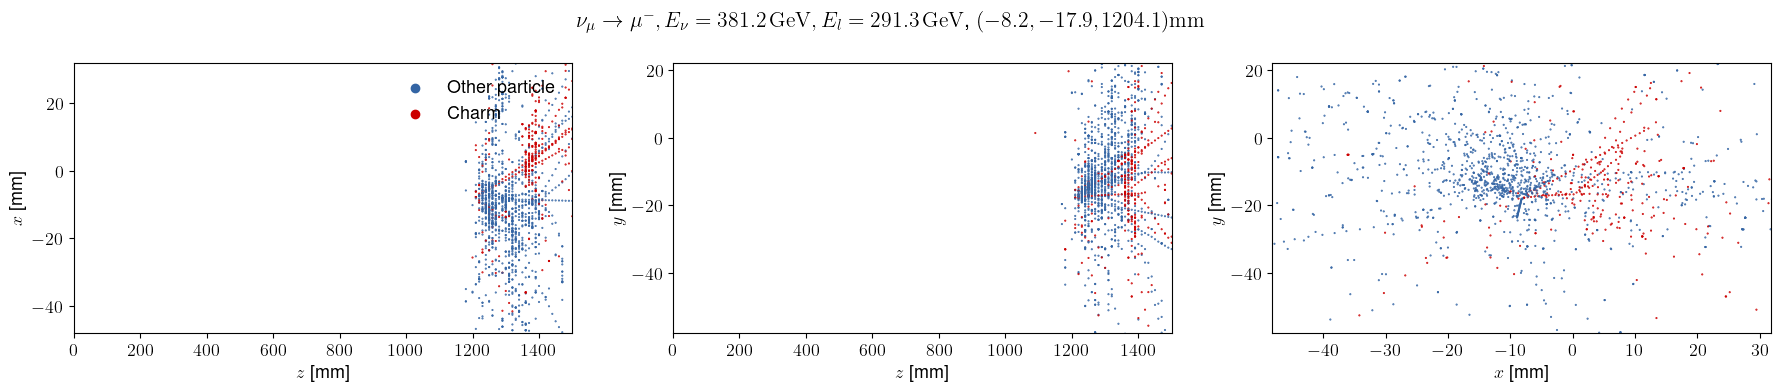

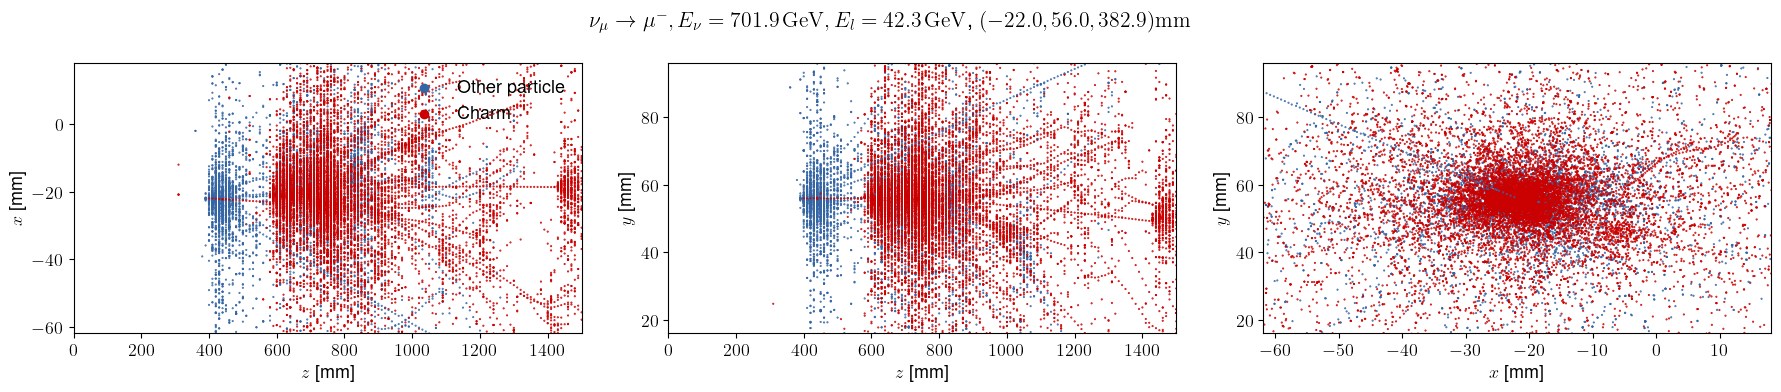

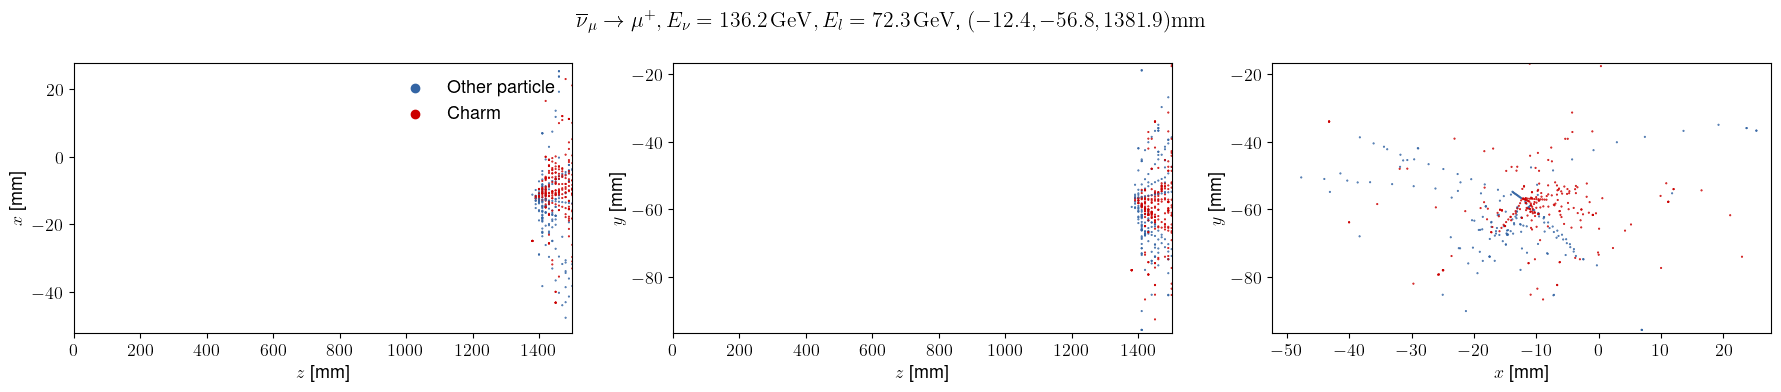

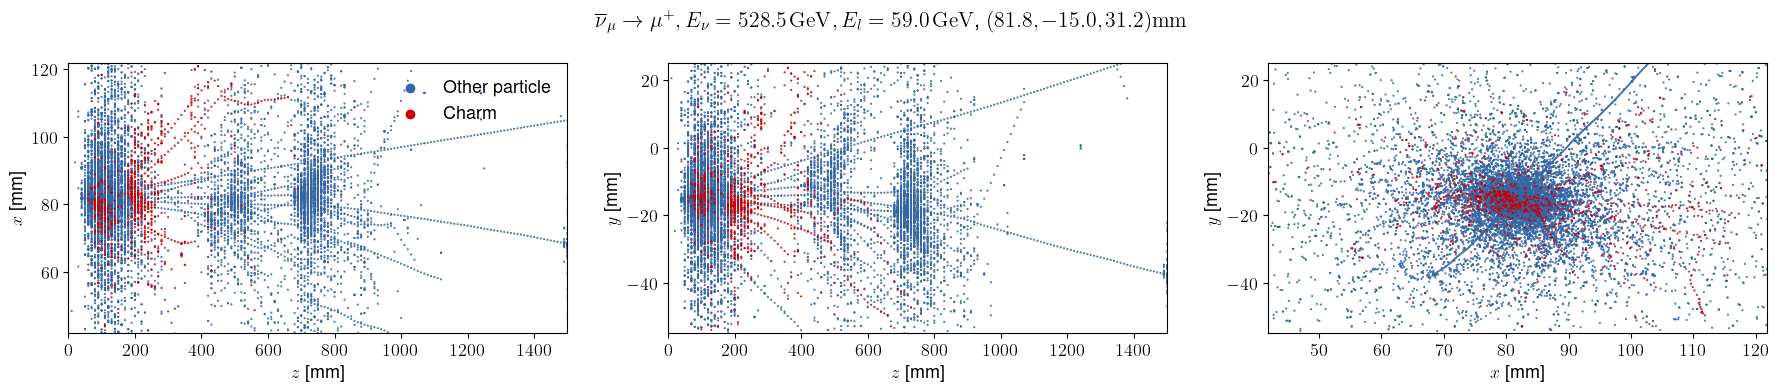

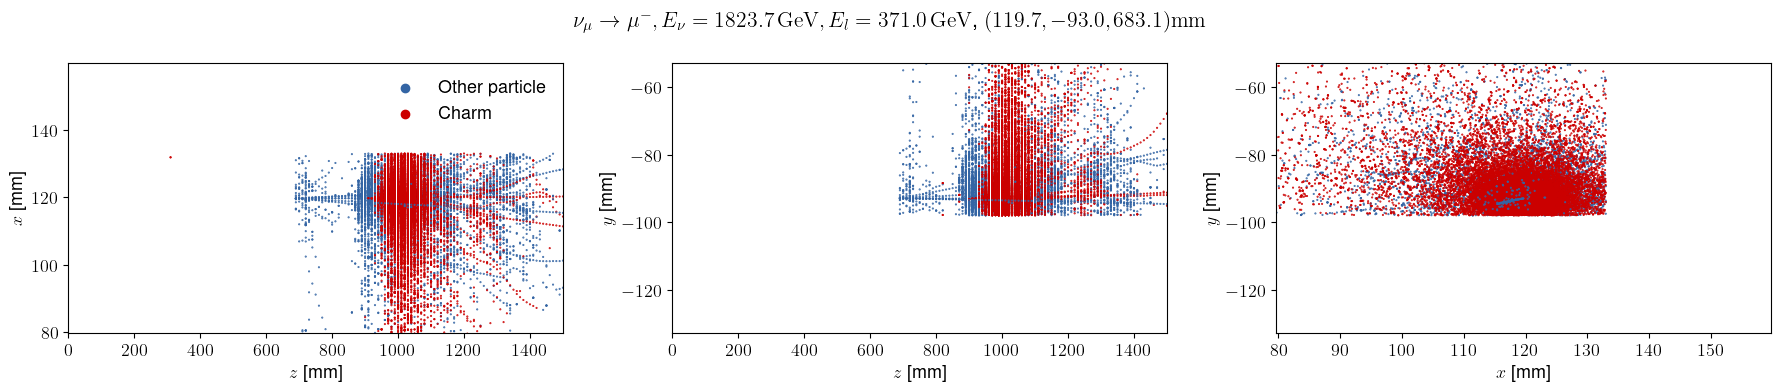

In [169]:
for event_id in charm_event_ids[:5]:
    plot_range = 40

    event_hits = hits_df.query(f"event_id == {event_id}").copy()
    truth: TruthParticle = get_truth_particle(truth_df.query(f"event_id == {event_id}"))

    event_hits["color"] = TangoColors.sky_blue
    event_hits["size"] = 1
    for i, (color, size) in enumerate(zip(colors, sizes)):
        event_hits.loc[event_hits["hit_fromCharmedHadron"] == True, "color"] = color
        # event_hits.loc[event_hits["hit_fromCharmedHadron"] == True, "size"] = size

    fig, axs = plt.subplots(1, 3, figsize=(6 * 3, 4))
    fig.suptitle(truth.get_latex_title())
    show_scatter_plots(
        df=event_hits,
        truth=truth,
        geo=geo,
        range=plot_range,
        axs=axs,
        color=event_hits["color"].values,
        s=event_hits["size"].values,
        # zlim=(0, 200)
    )
    for label, color in zip(latex_labels, colors):
        axs[0].scatter([], [], c=color, label=label)

    axs[0].legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # show_hist_plots(df=event_hits, truth=truth, geo=geo_200um, range=plot_range)